
Step 1 — 편향 측정 (Bias Measurement)

KuaiRec big_matrix를 분석:
  1) 아이템 인기도 분포 시각화 (long-tail, Lorenz)
  2) 노출 빈도 vs watch_ratio 상관관계
  3) "얼마나 편향돼 있는가" 정량화 (Gini, Pareto)


In [48]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
ROOT = Path("/content/drive/MyDrive/Research")

DATA_DIR = ROOT / "KuaiRec/data"
OUT_DIR = ROOT / "KuaiRec/output"

OUT_DIR.mkdir(parents=True, exist_ok=True)

# 한글 깨짐 방지 (환경 맞게 주석 해제)
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# 유틸
def gini_coefficient(x: np.ndarray) -> float:
    "배열 x의 Gini 계수. 0이면 완전 평등, 1에 가까울수록 불평등."
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

In [5]:
# 1. 데이터 로드

big = pd.read_csv(DATA_DIR / "big_matrix.csv")
print(f"big_matrix:  {big.shape[0]:>10,} rows × {big.shape[1]} cols")
print(f"  unique users: {big['user_id'].nunique():>8,}")
print(f"  unique items: {big['video_id'].nunique():>8,}")
print(f"  watch_ratio:  min={big['watch_ratio'].min():.3f}, "
      f"median={big['watch_ratio'].median():.3f}, "
      f"max={big['watch_ratio'].max():.3f}")

big_matrix:  12,530,806 rows × 8 cols
  unique users:    7,176
  unique items:   10,728
  watch_ratio:  min=0.000, median=0.723, max=573.457


In [6]:
# 2. 아이템 인기도 분포

item_stats = (
    big.groupby("video_id")
    .agg(
        exposure_count=("user_id", "count"),
        unique_users=("user_id", "nunique"),
        avg_watch_ratio=("watch_ratio", "mean"),
        median_watch_ratio=("watch_ratio", "median"),
    )
    .reset_index()
    .sort_values("exposure_count", ascending=False)
    .reset_index(drop=True)
)

print(f"top item:    {item_stats.iloc[0]['exposure_count']:>10,.0f} exposures")
print(f"median item: {item_stats['exposure_count'].median():>10,.0f} exposures")
print(f"bottom item: {item_stats.iloc[-1]['exposure_count']:>10,.0f} exposures")

# Gini 계수
g = gini_coefficient(item_stats["exposure_count"].values)
print(f"\nGini coefficient (item exposure): {g:.4f}")
print("  (0=완전평등, 1=완전불평등 — 0.6 이상이면 강한 long-tail)")

# Pareto 검증: 상위 X% 아이템이 전체 노출의 몇 %를 차지하는가
print("\nPareto check:")
total_exp = item_stats["exposure_count"].sum()
for pct in [1, 5, 10, 20, 30]:
    top_n = max(int(len(item_stats) * pct / 100), 1)
    share = item_stats.head(top_n)["exposure_count"].sum() / total_exp
    print(f"  top {pct:>2}% items ({top_n:>4} items) → "
          f"{share * 100:5.1f}% of total exposures")

top item:        27,615 exposures
median item:        243 exposures
bottom item:          1 exposures

Gini coefficient (item exposure): 0.6722
  (0=완전평등, 1=완전불평등 — 0.6 이상이면 강한 long-tail)

Pareto check:
  top  1% items ( 107 items) →   6.0% of total exposures
  top  5% items ( 536 items) →  23.3% of total exposures
  top 10% items (1072 items) →  40.7% of total exposures
  top 20% items (2145 items) →  66.4% of total exposures
  top 30% items (3218 items) →  84.7% of total exposures


In [ ]:
# Gini 0.67, top 10%가 41% 차지
# 편향은 확실히 있음


[saved] /content/drive/MyDrive/Research/KuaiRec/output/01_popularity_distribution.png


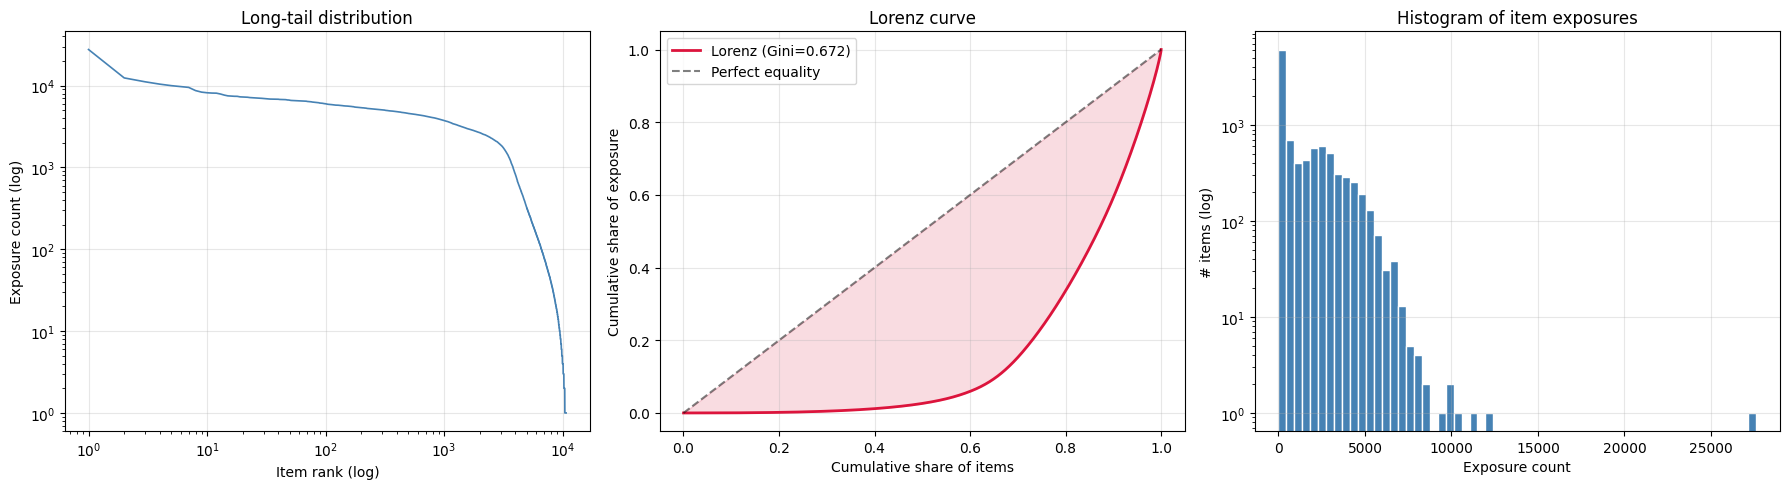

In [7]:
# 3. 시각화: long-tail / Lorenz / 히스토그램

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rank vs frequency (log-log) — long-tail
ax = axes[0]
ax.plot(np.arange(1, len(item_stats) + 1), item_stats["exposure_count"].values,
        color="steelblue", linewidth=1.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Item rank (log)")
ax.set_ylabel("Exposure count (log)")
ax.set_title("Long-tail distribution")
ax.grid(True, alpha=0.3)

# (b) Lorenz curve
ax = axes[1]
sorted_counts = np.sort(item_stats["exposure_count"].values)
cum_share = np.cumsum(sorted_counts) / sorted_counts.sum()
x = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax.plot(x, cum_share, color="crimson", linewidth=2,
        label=f"Lorenz (Gini={g:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect equality")
ax.fill_between(x, x, cum_share, alpha=0.15, color="crimson")
ax.set_xlabel("Cumulative share of items")
ax.set_ylabel("Cumulative share of exposure")
ax.set_title("Lorenz curve")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# (c) Histogram
ax = axes[2]
ax.hist(item_stats["exposure_count"], bins=60, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Exposure count")
ax.set_ylabel("# items (log)")
ax.set_title("Histogram of item exposures")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "01_popularity_distribution.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '01_popularity_distribution.png'}")

Spearman ρ = -0.2987  (p=6.43e-220)
Pearson  r = -0.0882  (p=5.64e-20)

Quintile analysis:
                     n_items  avg_exposure  avg_watch_ratio  std_watch_ratio
popularity_quintile                                                         
Q1\n(least popular)     2146      9.227400         2.001412         4.374573
Q2                      2145     59.833100         1.137758         1.593104
Q3                      2146    278.078285         0.989955         0.474161
Q4                      2145   1616.061538         0.949168         0.404787
Q5\n(most popular)      2146   3876.726002         0.940138         0.386095

[saved] /content/drive/MyDrive/Research/KuaiRec/output/02_exposure_vs_engagement.png


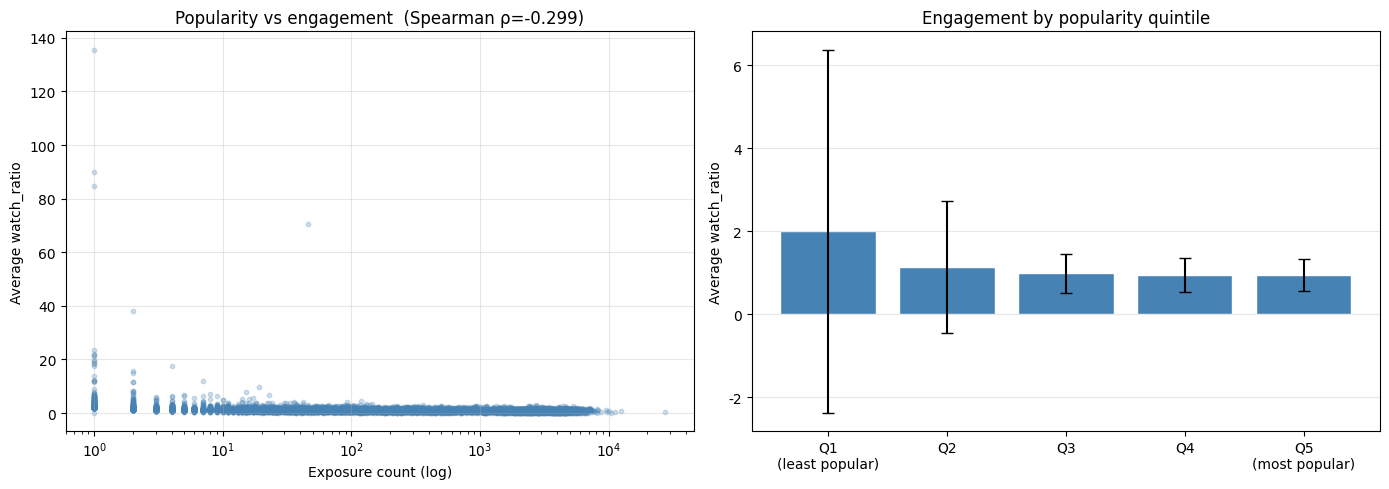

In [8]:
# 4. 노출 빈도 vs watch_ratio 상관관계

rho, p_rho = spearmanr(item_stats["exposure_count"], item_stats["avg_watch_ratio"])
r, p_r = pearsonr(item_stats["exposure_count"], item_stats["avg_watch_ratio"])
print(f"Spearman ρ = {rho:+.4f}  (p={p_rho:.2e})")
print(f"Pearson  r = {r:+.4f}  (p={p_r:.2e})")

# 5분위 분석
item_stats["popularity_quintile"] = pd.qcut(
    item_stats["exposure_count"].rank(method="first"),
    q=5,
    labels=["Q1\n(least popular)", "Q2", "Q3", "Q4", "Q5\n(most popular)"],
)
qstats = item_stats.groupby("popularity_quintile").agg(
    n_items=("video_id", "count"),
    avg_exposure=("exposure_count", "mean"),
    avg_watch_ratio=("avg_watch_ratio", "mean"),
    std_watch_ratio=("avg_watch_ratio", "std"),
)
print("\nQuintile analysis:")
print(qstats.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(item_stats["exposure_count"], item_stats["avg_watch_ratio"],
           alpha=0.25, s=10, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel("Average watch_ratio")
ax.set_title(f"Popularity vs engagement  (Spearman ρ={rho:+.3f})")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(
    range(len(qstats)),
    qstats["avg_watch_ratio"],
    yerr=qstats["std_watch_ratio"],
    color="steelblue",
    capsize=4,
    edgecolor="white",
)
ax.set_xticks(range(len(qstats)))
ax.set_xticklabels(qstats.index)
ax.set_ylabel("Average watch_ratio")
ax.set_title("Engagement by popularity quintile")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(OUT_DIR / "02_exposure_vs_engagement.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '02_exposure_vs_engagement.png'}")

In [ ]:
# Spearman ρ = −0.30, Pearson r = −0.09
# 인기 있을수록 watch_ratio가 낮아지는 방향
# "추천된 게 인기 있어서가 아니라, 노출돼서 인기 있어진거다"라는 가설을 지지함

# Q1의 평균 노출 9.2번, std 4.37은 평균 2.0보다 2배 이상 크다는 뜻 — 분포가 헝클어져 있음
# 산점도 왼쪽 위에 점 몇 개 (140 근처)가 보이는데 얘네가 평균을 다 끌어올린 것
# 즉, Q1의 2.0은 "Q1이 진짜 더 좋아서"가 아니라 표본이 적은 데서 outlier가 평균을 흔든 것

# 표본이 충분히 모인 분위 안에서는 노출이 4배(278→1616), 14배(278→3877) 늘어나도 평균 watch_ratio는 거의 안 변함
# 즉, "인기는 노출의 결과지 선호의 결과가 아니다"

Step 1b — watch_ratio capping 후 편향 측정 재실행

이전 결과의 Q1 outlier 문제를 해소하기 위해 watch_ratio에 상한을 두고 quintile 분석과 상관관계를 다시 계산

big_matrix: 12,530,806 rows
watch_ratio (raw): min=0.000, median=0.723, max=573.457
watch_ratio > 2.0 인 비율: 7.47%
watch_ratio > 5.0 인 비율: 0.92%
   cap  spearman  pearson  Q1_avg_wr  Q1_std_wr  Q3_avg_wr  Q5_avg_wr  Q5/Q3_ratio
no cap   -0.2987  -0.0882      2.001      4.375      0.990      0.940        0.950
   1.0   -0.2076  -0.1234      0.768      0.212      0.652      0.643        0.986
   2.0   -0.2811  -0.2110      1.234      0.495      0.858      0.806        0.940
   3.0   -0.3086  -0.2256      1.450      0.687      0.911      0.851        0.934
   5.0   -0.3176  -0.2189      1.607      0.934      0.941      0.883        0.938
  10.0   -0.3164  -0.1984      1.733      1.291      0.964      0.908        0.942
[BEFORE — no cap]
          n_items  avg_exposure  avg_watch_ratio  std_watch_ratio
quintile                                                         
Q1           2146         9.227            2.001            4.375
Q2           2145        59.833            1.138           

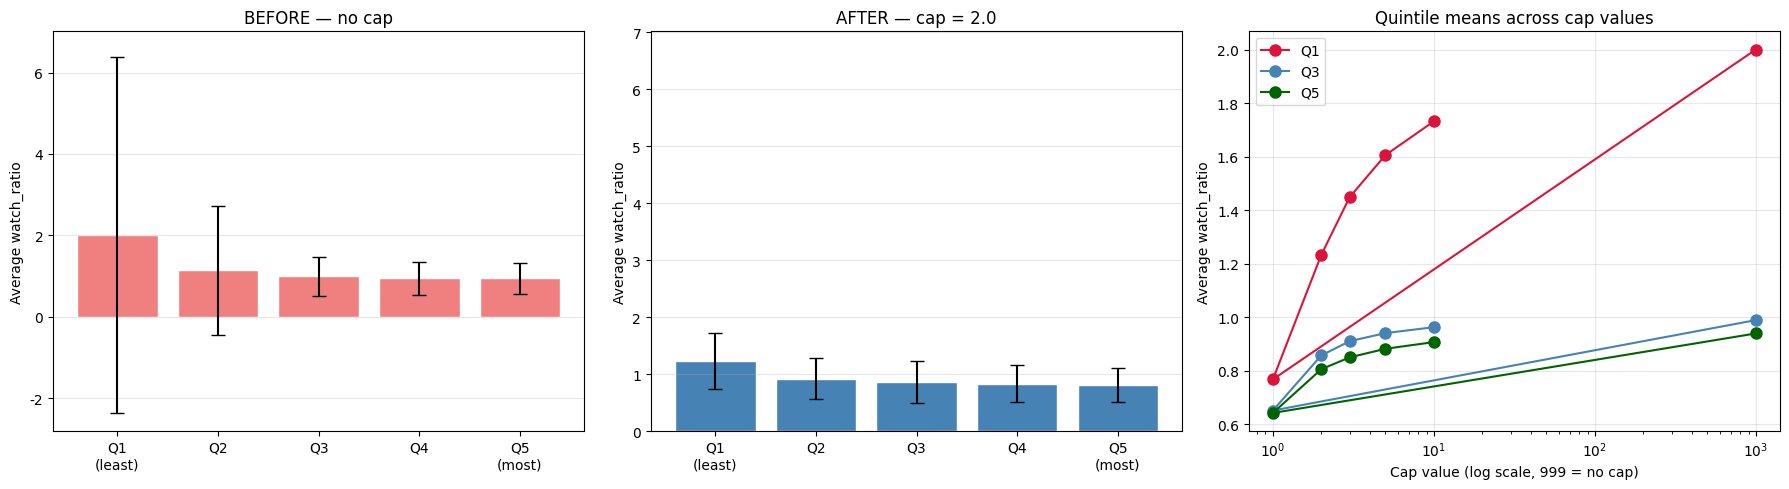

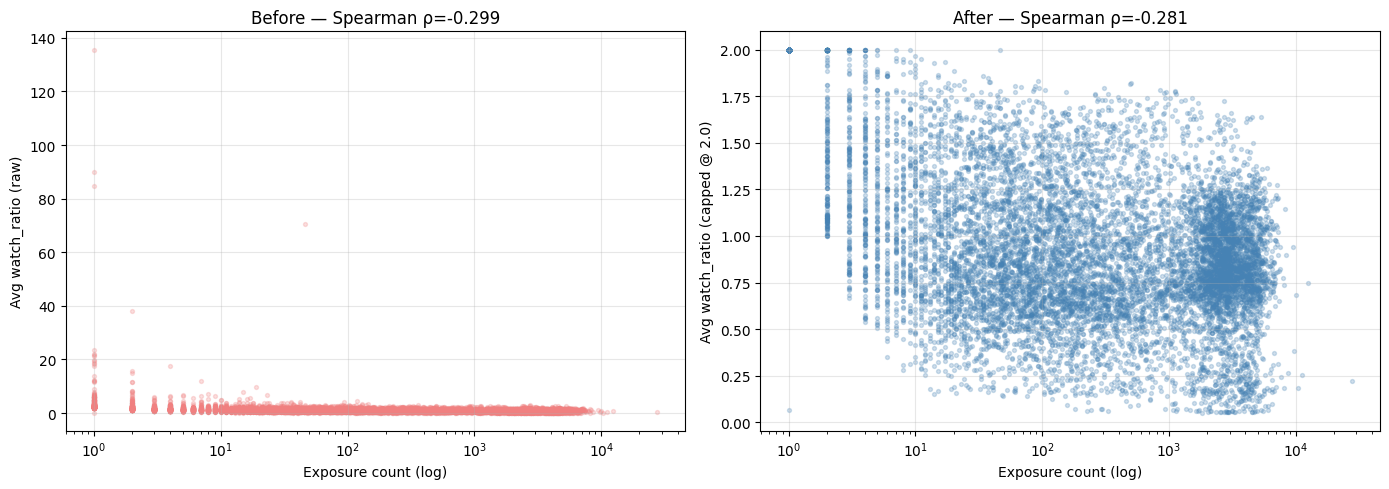

In [31]:
DEFAULT_CAP = 2.0  # 메인 cap 값
SENSITIVITY_CAPS = [None, 1.0, 2.0, 3.0, 5.0, 10.0]  # 비교용


def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)


# 1. 데이터 로드

big = pd.read_csv(DATA_DIR / "big_matrix.csv")
print(f"big_matrix: {len(big):,} rows")
print(f"watch_ratio (raw): min={big['watch_ratio'].min():.3f}, "
      f"median={big['watch_ratio'].median():.3f}, "
      f"max={big['watch_ratio'].max():.3f}")
print(f"watch_ratio > 2.0 인 비율: "
      f"{(big['watch_ratio'] > 2.0).mean() * 100:.2f}%")
print(f"watch_ratio > 5.0 인 비율: "
      f"{(big['watch_ratio'] > 5.0).mean() * 100:.2f}%")

# 2. cap별로 item_stats 재계산

def compute_item_stats(big_df: pd.DataFrame, cap: float | None) -> pd.DataFrame:
    """주어진 cap으로 watch_ratio를 clipping해 아이템 단위 집계."""
    wr = big_df["watch_ratio"] if cap is None else big_df["watch_ratio"].clip(upper=cap)
    tmp = big_df[["user_id", "video_id"]].assign(watch_ratio=wr.values)
    return (
        tmp.groupby("video_id")
        .agg(
            exposure_count=("user_id", "count"),
            avg_watch_ratio=("watch_ratio", "mean"),
            median_watch_ratio=("watch_ratio", "median"),
        )
        .reset_index()
        .sort_values("exposure_count", ascending=False)
        .reset_index(drop=True)
    )


def quintile_summary(stats: pd.DataFrame) -> pd.DataFrame:
    stats = stats.copy()
    stats["quintile"] = pd.qcut(
        stats["exposure_count"].rank(method="first"),
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    )
    return stats.groupby("quintile").agg(
        n_items=("video_id", "count"),
        avg_exposure=("exposure_count", "mean"),
        avg_watch_ratio=("avg_watch_ratio", "mean"),
        std_watch_ratio=("avg_watch_ratio", "std"),
    )



# 3. Sensitivity: 여러 cap에 대해 핵심 지표 비교

rows = []
qtables = {}
for cap in SENSITIVITY_CAPS:
    s = compute_item_stats(big, cap)
    rho, _ = spearmanr(s["exposure_count"], s["avg_watch_ratio"])
    r, _ = pearsonr(s["exposure_count"], s["avg_watch_ratio"])
    q = quintile_summary(s)
    qtables[cap] = q
    rows.append({
        "cap": "no cap" if cap is None else f"{cap:.1f}",
        "spearman": round(rho, 4),
        "pearson": round(r, 4),
        "Q1_avg_wr": round(q.loc["Q1", "avg_watch_ratio"], 3),
        "Q1_std_wr": round(q.loc["Q1", "std_watch_ratio"], 3),
        "Q3_avg_wr": round(q.loc["Q3", "avg_watch_ratio"], 3),
        "Q5_avg_wr": round(q.loc["Q5", "avg_watch_ratio"], 3),
        "Q5/Q3_ratio": round(
            q.loc["Q5", "avg_watch_ratio"] / q.loc["Q3", "avg_watch_ratio"], 3
        ),
    })

sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

# 4. 메인 cap (=DEFAULT_CAP) 결과 상세

stats_raw = compute_item_stats(big, None)
stats_cap = compute_item_stats(big, DEFAULT_CAP)

q_raw = quintile_summary(stats_raw)
q_cap = quintile_summary(stats_cap)

print("[BEFORE — no cap]")
print(q_raw.round(3).to_string())
print("\n[AFTER — cap=2.0]")
print(q_cap.round(3).to_string())

rho_cap, _ = spearmanr(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"])
r_cap, _ = pearsonr(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"])
print(f"\nAfter cap=2.0:  Spearman ρ = {rho_cap:+.4f}, Pearson r = {r_cap:+.4f}")


# 5. 시각화: Before vs After quintile bars

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(5)
labels = ["Q1\n(least)", "Q2", "Q3", "Q4", "Q5\n(most)"]

# (a) Before
ax = axes[0]
ax.bar(x, q_raw["avg_watch_ratio"], yerr=q_raw["std_watch_ratio"],
       color="lightcoral", capsize=5, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average watch_ratio")
ax.set_title("BEFORE — no cap")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))

# (b) After
ax = axes[1]
ax.bar(x, q_cap["avg_watch_ratio"], yerr=q_cap["std_watch_ratio"],
       color="steelblue", capsize=5, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average watch_ratio")
ax.set_title(f"AFTER — cap = {DEFAULT_CAP}")
ax.grid(True, alpha=0.3, axis="y")

# y축 두 그래프 통일
ymax = max(
    (q_raw["avg_watch_ratio"] + q_raw["std_watch_ratio"]).max(),
    (q_cap["avg_watch_ratio"] + q_cap["std_watch_ratio"]).max(),
) * 1.1
axes[0].set_ylim(top=ymax)
axes[1].set_ylim(top=ymax)

# (c) cap별 Q1, Q3, Q5 trend
ax = axes[2]
caps_x = [c if c is not None else 999 for c in SENSITIVITY_CAPS]
for q_name, color in [("Q1", "crimson"), ("Q3", "steelblue"), ("Q5", "darkgreen")]:
    vals = [qtables[c].loc[q_name, "avg_watch_ratio"] for c in SENSITIVITY_CAPS]
    ax.plot(caps_x, vals, "o-", color=color, label=q_name, markersize=8)
ax.set_xscale("log")
ax.set_xlabel("Cap value (log scale, 999 = no cap)")
ax.set_ylabel("Average watch_ratio")
ax.set_title("Quintile means across cap values")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "02b_quintile_capped.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '02b_quintile_capped.png'}")


# 6. capped scatter (전체 데이터에서)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(stats_raw["exposure_count"], stats_raw["avg_watch_ratio"],
           alpha=0.25, s=8, color="lightcoral")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel("Avg watch_ratio (raw)")
ax.set_title(f"Before — Spearman ρ={spearmanr(stats_raw['exposure_count'], stats_raw['avg_watch_ratio'])[0]:+.3f}")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"],
           alpha=0.25, s=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel(f"Avg watch_ratio (capped @ {DEFAULT_CAP})")
ax.set_title(f"After — Spearman ρ={rho_cap:+.3f}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "02c_scatter_capped.png", dpi=120)
print(f"[saved] {OUT_DIR / '02c_scatter_capped.png'}")


# 7. 결과 저장

stats_cap.to_csv(OUT_DIR / "item_stats_capped.csv", index=False)
sens.to_csv(OUT_DIR / "cap_sensitivity.csv", index=False)
print(f"[saved] {OUT_DIR / 'item_stats_capped.csv'}")
print(f"[saved] {OUT_DIR / 'cap_sensitivity.csv'}")

In [ ]:
# cap값이 다르다는 게 무슨 의미인가?
# watch_ratio를 어디서 자르는지가 무슨 행동을 측정하느냐

# cap=1.0: 1을 넘는 값은 다 1로 자름 → "한 번 끝까지 봤는가?"만 봄, 두 번 보든 열 번 보든 똑같이 1
# cap=2.0: 1.0~2.0 구간은 살아남음 → "끝까지 봤는가? + 한 번 더 봤는가?"까지 봄, 그 이상의 반복 시청은 다 2로 잘림
# cap 없음: 반복 시청 횟수가 그대로 반영됨, 같은 영상 100번 보면 watch_ratio=100

# 즉 cap을 1.0 → 2.0으로 올린다는 건 "반복 시청 신호를 분석에 더 많이 넣는다"는 뜻

In [ ]:
# Spearman: -0.299 → -0.281 / 분포 변형에 robust → cap별로 큰 차이 없음
# Pearson" -0.088 → -0.211 / cap에 따라 크게 흔들림

# Q1 std: 4.375 → 0.495 / 9배 감소 ->cap이 내려갈수록 Q1의 outlier가 정리됨
# Q1 평균: 2.001 → 1.234 / 거품 빠짐

# Q1: 1.234 → Q2: 0.919 → Q3: 0.858 → Q4: 0.833 → Q5: 0.806
# 단조 감소 / 노출이 많을수록 평균 watch_ratio가 오히려 낮다 !

In [ ]:
# cap=1.0 vs cap=2.0
# cap=1.0: Q5/Q3 = 0.986 / "한 번 끝까지 보는 비율"은 인기 영상이나 중간 인기 영상이나 비슷
# cap=2.0: Q5/Q3 = 0.940 / 반복 시청은 Q3(중간 인기) 영상에서 Q5(최상위 인기) 영상보다 더 자주 일어남

# 완전 시청만 보면 Q5와 Q3가 비슷
# 반복 시청까지 포함하면 Q3(중간 인기)가 Q5(상위 인기)를 앞섬
# 즉, long-tail에 가까운 아이템일수록 "푹 빠지는 유저"의 비율이 높다

In [9]:
# 5. 사이드 — 유저 단위 편향도 (참고용)

user_activity = big.groupby("user_id").size()
g_user = gini_coefficient(user_activity.values)
print(f"User-side Gini: {g_user:.4f}")
print(f"  active heavy user (top 10%) sees "
      f"{user_activity.quantile(0.9):,.0f}+ items")
print(f"  median user sees {user_activity.median():,.0f} items")

User-side Gini: 0.3179
  active heavy user (top 10%) sees 2,912+ items
  median user sees 1,846 items


In [11]:
# 6. 결과 저장

item_stats.drop(columns=["popularity_quintile"]).to_csv(
    OUT_DIR / "item_stats.csv", index=False
)
print(f"[saved] {OUT_DIR / 'item_stats.csv'}")

# 한 줄 summary
summary = pd.DataFrame(
    [{
        "n_users": big["user_id"].nunique(),
        "n_items": big["video_id"].nunique(),
        "n_interactions": len(big),
        "item_gini": round(g, 4),
        "user_gini": round(g_user, 4),
        "spearman_pop_vs_watch": round(rho, 4),
        "pearson_pop_vs_watch": round(r, 4),
        "top10pct_items_share": round(
            item_stats.head(int(len(item_stats) * 0.1))["exposure_count"].sum()
            / total_exp,
            4,
        ),
    }]
)
summary.to_csv(OUT_DIR / "bias_summary.csv", index=False)
print(f"[saved] {OUT_DIR / 'bias_summary.csv'}")
print("\n" + summary.T.to_string())

[saved] /content/drive/MyDrive/Research/KuaiRec/output/item_stats.csv
[saved] /content/drive/MyDrive/Research/KuaiRec/output/bias_summary.csv

                                  0
n_users                7.176000e+03
n_items                1.072800e+04
n_interactions         1.253081e+07
item_gini              6.722000e-01
user_gini              3.179000e-01
spearman_pop_vs_watch -2.987000e-01
pearson_pop_vs_watch  -8.820000e-02
top10pct_items_share   4.069000e-01


In [32]:
big.groupby("video_id").agg(
    duration=("video_duration", "mean"),
    exposure=("user_id", "count"),
).corr()

# exposure ↔ duration 상관이 약함 (|ρ| < 0.2)

,duration,exposure
duration,1.000000,0.092988
exposure,0.092988,1.000000


Step 2 — Propensity Score 계산

In [ ]:
# small_matrix의 (user × item) 영역은 big_matrix에서 통째로 제외돼 있음.
# → small_matrix는 propensity 계산용이 아니라 Step 3 평가용(unbiased GT).
# → propensity는 big_matrix 단독으로 추정

#  popularity 기반:  p_i ∝ pop_i^α
# α를 [0.3, 0.5, 0.7, 1.0]에 대해 sweep, 0.5가 표준값.

In [38]:
# 설정

ALPHAS = [0.3, 0.5, 0.7, 1.0]
DEFAULT_ALPHA = 0.5
CLIP_MIN = 0.01
CLIP_MAX = 1.0

def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

In [39]:
# 1. 데이터 로드

small = pd.read_csv(DATA_DIR / "small_matrix.csv")

n_users = big["user_id"].nunique()
n_items_big = big["video_id"].nunique()
small_items = set(small["video_id"].unique())

print(f"big:   {len(big):>10,} rows  ({n_users:,} users × {n_items_big:,} items)")
print(f"small: {len(small):>10,} rows  (eval set: {len(small_items):,} items)")

big:   12,530,806 rows  (7,176 users × 10,728 items)
small:  4,676,570 rows  (eval set: 3,327 items)


In [40]:
# 2. popularity 기반 propensity

# 아이템별 노출 횟수 (big_matrix 전체)
item_pop = big.groupby("video_id").size().rename("exposure_count")
print(f"item coverage in big: {len(item_pop):,} / {n_items_big:,}")

# α 값별로 propensity 계산
def compute_p_alpha(pop: pd.Series, alpha: float) -> pd.Series:
    """p_i ∝ pop_i^α, max-normalize 후 clipping."""
    raw = pop.values.astype(float) ** alpha
    return pd.Series(
        np.clip(raw / raw.max(), CLIP_MIN, CLIP_MAX),
        index=pop.index,
        name=f"p_alpha_{alpha}",
    )

p_dict = {alpha: compute_p_alpha(item_pop, alpha) for alpha in ALPHAS}

# 단순 빈도 기반 (참고용 baseline)
p_naive = (item_pop / n_users).clip(CLIP_MIN, CLIP_MAX).rename("p_naive")

# small_items 한정 통계
print(f"\nDistribution on small_items (n={len(small_items):,}, 평가 대상):")
header = f"  {'method':<14} {'min':>7} {'25%':>7} {'med':>7} {'75%':>7} {'max':>7}"
print(header)
for alpha in ALPHAS:
    s = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    q = s.quantile([0.0, 0.25, 0.5, 0.75, 1.0])
    print(f"  α={alpha:<10}    {q.iloc[0]:>7.4f} {q.iloc[1]:>7.4f} "
          f"{q.iloc[2]:>7.4f} {q.iloc[3]:>7.4f} {q.iloc[4]:>7.4f}")

item coverage in big: 10,728 / 10,728

Distribution on small_items (n=3,327, 평가 대상):
  method             min     25%     med     75%     max
  α=0.3            0.0705  0.4646  0.5050  0.5584  1.0000
  α=0.5            0.0120  0.2787  0.3202  0.3787  1.0000
  α=0.7            0.0100  0.1672  0.2031  0.2568  1.0000
  α=1.0            0.0100  0.0777  0.1026  0.1434  1.0000


In [46]:
# 3. Sanity check: quintile별 propensity 단조 증가 여부

# popularity quintile (small_items 내에서)
small_pop = item_pop.loc[item_pop.index.isin(small_items)].copy()
quintile = pd.qcut(
    small_pop.rank(method="first"), q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
)
quintile_df = pd.DataFrame({"pop": small_pop, "quintile": quintile})

q_compare = pd.DataFrame(index=["Q1", "Q2", "Q3", "Q4", "Q5"])
for alpha in ALPHAS:
    p = p_dict[alpha].loc[
    p_dict[alpha].index.intersection(small_items)
]
    q_compare[f"α={alpha}"] = quintile_df.assign(p=p).groupby("quintile")["p"].mean()

print(q_compare.round(4).to_string())

     α=0.3   α=0.5   α=0.7   α=1.0
Q1  0.4013  0.2217  0.1235  0.0520
Q2  0.4733  0.2875  0.1747  0.0828
Q3  0.5049  0.3202  0.2031  0.1026
Q4  0.5454  0.3643  0.2433  0.1329
Q5  0.6043  0.4327  0.3102  0.1890


In [43]:
# 4. IPW weight diagnostics — α 선택의 핵심 정보

ipw_stats = []
for alpha in ALPHAS:
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    w = 1.0 / p
    ipw_stats.append({
        "alpha": alpha,
        "weight_mean": w.mean(),
        "weight_median": w.median(),
        "weight_max": w.max(),
        "weight_p99": w.quantile(0.99),
        "weight_p95/p50": w.quantile(0.95) / w.quantile(0.50),
    })
ipw_df = pd.DataFrame(ipw_stats)
print(ipw_df.round(3).to_string(index=False))

 alpha  weight_mean  weight_median  weight_max  weight_p99  weight_p95/p50
   0.3        2.047          1.980      14.182       3.654           1.294
   0.5        3.433          3.123      83.089       8.668           1.537
   0.7        5.740          4.924     100.000      20.562           1.825
   1.0       11.977          9.751     100.000      75.133           2.362


In [ ]:
# α↓ → propensity가 평탄해짐 → weight도 평탄 → 학습 안정 / 보정 약함
# α↑ → propensity 가파름 → weight 분산 큼 → 학습 불안정 / 보정 강함
# p95/p50 비율: 가중치 분산의 직관적 지표 (모두 10 이하 안전)


[saved] /content/drive/MyDrive/Research/KuaiRec/output/04_propensity_alpha.png


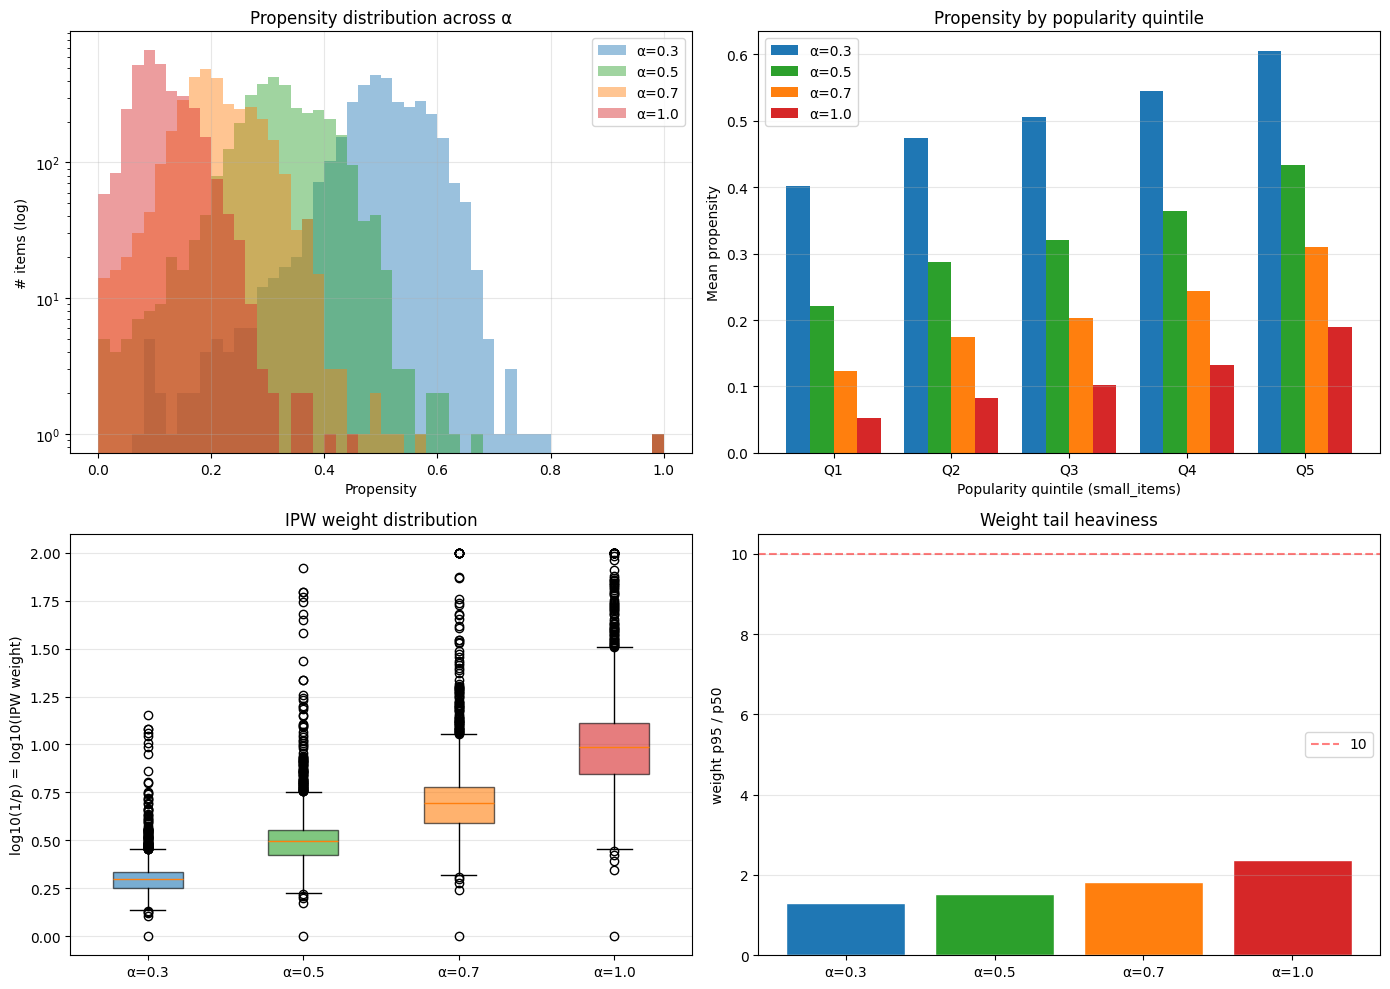

In [52]:
# 5. 시각화 (4-panel)

warnings.filterwarnings("ignore")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

# (a) α별 propensity 분포
ax = axes[0, 0]
bins = np.linspace(0, 1, 51)
for alpha, c in zip(ALPHAS, colors):
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    ax.hist(p, bins=bins, alpha=0.45, label=f"α={alpha}", color=c)
ax.set_yscale("log")
ax.set_xlabel("Propensity")
ax.set_ylabel("# items (log)")
ax.set_title("Propensity distribution across α")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) quintile별 평균 propensity
ax = axes[0, 1]
x = np.arange(5)
width = 0.2
for i, alpha in enumerate(ALPHAS):
    ax.bar(x + (i - 1.5) * width, q_compare[f"α={alpha}"], width,
           label=f"α={alpha}", color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
ax.set_xlabel("Popularity quintile (small_items)")
ax.set_ylabel("Mean propensity")
ax.set_title("Propensity by popularity quintile")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# (c) IPW weight 분포 (boxplot, log scale)
ax = axes[1, 0]
data = []
for alpha in ALPHAS:
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    data.append(np.log10(1.0 / p))
bp = ax.boxplot(data, tick_labels=[f"α={a}" for a in ALPHAS],
                showfliers=True, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_ylabel("log10(1/p) = log10(IPW weight)")
ax.set_title("IPW weight distribution")
ax.grid(True, alpha=0.3, axis="y")

# (d) p95/p50 ratio - 분산 비교
ax = axes[1, 1]
ax.bar(range(len(ALPHAS)), ipw_df["weight_p95/p50"],
       color=colors, edgecolor="white")
ax.set_xticks(range(len(ALPHAS)))
ax.set_xticklabels([f"α={a}" for a in ALPHAS])
ax.set_ylabel("weight p95 / p50")
ax.set_title("Weight tail heaviness")
ax.axhline(10, color="red", linestyle="--", alpha=0.5, label="10")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(OUT_DIR / "04_propensity_alpha.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '04_propensity_alpha.png'}")

In [ ]:
# (a) α=0.3은 평균 0.5 근처에 모여 있음
# 즉 거의 균등 가중치라 IPW 보정이 약함
# α↑할수록 분포가 왼쪽(0 근처)으로 끌려가고 long-tail item에 큰 weight가 붙음
# 즉, "low propensity item에 IPS 보정으로 더 많이 올려주자"

# (b) 모든 α에서 깔끔하게 단조 증가
# 추천 시스템이 인기 있는 아이템을 더 많이 노출했고, 우리 propensity가 그걸 잘 포착했음

In [53]:
# 6. 결과 저장

# (a) Step 3에서 바로 쓸 default propensity (모든 big items 포함)
default = p_dict[DEFAULT_ALPHA].rename("propensity")
out_main = pd.DataFrame({
    "video_id": default.index,
    "exposure_count": item_pop.loc[default.index].values,
    "propensity": default.values,
    "in_small_items": [vid in small_items for vid in default.index],
})
out_main.to_csv(OUT_DIR / "propensity_final.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_final.csv'}  "
      f"(α={DEFAULT_ALPHA}, n={len(out_main):,} items)")

# (b) α별 비교 테이블 (small_items 한정)
sweep = pd.DataFrame({"video_id": list(small_items & set(item_pop.index))})
sweep["exposure_count"] = sweep["video_id"].map(item_pop)
for alpha in ALPHAS:
    sweep[f"p_alpha_{alpha}"] = sweep["video_id"].map(p_dict[alpha])
sweep = sweep.sort_values("exposure_count", ascending=False).reset_index(drop=True)
sweep.to_csv(OUT_DIR / "propensity_alpha_sweep.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_alpha_sweep.csv'}")

# (c) α 진단 통계
ipw_df.to_csv(OUT_DIR / "propensity_alpha_diagnostics.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_alpha_diagnostics.csv'}")

[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_final.csv  (α=0.5, n=10,728 items)
[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_alpha_sweep.csv
[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_alpha_diagnostics.csv
